#  Edge and Contour Detection 

## PART A

### Import the Required Libraries

In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Load Image

In [23]:
image = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Object.png")
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

### Canny Edge Detector

(np.float64(-0.5), np.float64(1447.5), np.float64(1085.5), np.float64(-0.5))

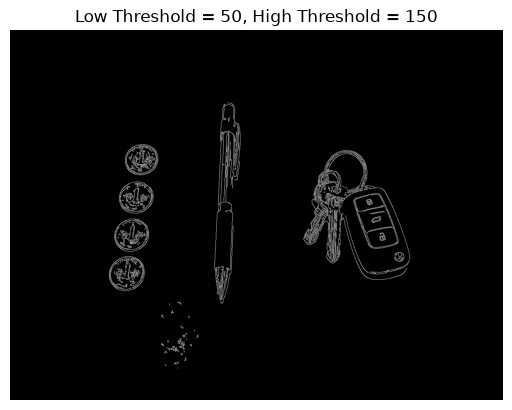

In [24]:
canny = cv2.Canny(image_gray,50,150)
plt.imshow(canny, cmap="gray")
plt.title("Low Threshold = 50, High Threshold = 150")
plt.axis('off')

### Tune the Thresholds

Enter lower threshold:  40
Enter upper threshold:  150


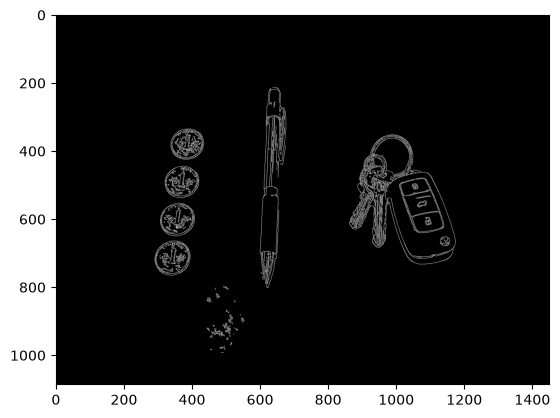

Satisfied? (y/n):  n
Enter lower threshold:  30
Enter upper threshold:  200


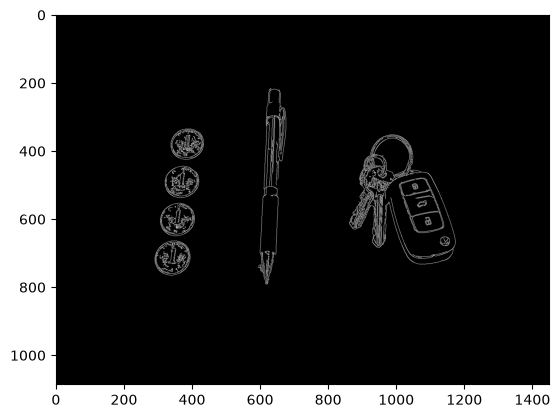

Satisfied? (y/n):  y


In [38]:
while True:
    low_threshold = int(input("Enter lower threshold: "))
    high_threshold = int(input("Enter upper threshold: "))
    edges = cv2.Canny(image_gray,low_threshold,high_threshold)
    plt.imshow(edges, cmap="gray")
    plt.show()
    key = cv2.waitKey(1)
    done = input("Satisfied? (y/n): ")
    if done.lower() == 'y':
        break

In [39]:
print(f"Final thresholds: ({low_threshold}, {high_threshold})")

Final thresholds: (30, 200)


### Note

Final Thresholds : (30,100)

Number of tuning attempts: 2

## PART B

### Find Contours

In [46]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("Auto-counted Number of Objects: ",len(contours))

Auto-counted Number of Objects:  372


### Mismatch

The contour count was much larger than the actual object count because Canny detected many internal object details (coin engravings, key teeth, pen clip edges), producing hundreds of disconnected contour fragments.

### Fix

In [48]:
kernel = np.ones((7,7), np.uint8)

closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel
)

contours, _ = cv2.findContours(
    closed,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [49]:
print("Number of Objects Found: ",len(contours))

Number of Objects Found:  6


### Annotated Image

In [58]:
annotated = image.copy()

cv2.drawContours(
    annotated,
    contours,
    -1,
    (0, 255, 0),
    2
)

array([[[171, 182, 188],
        [174, 185, 192],
        [175, 186, 193],
        ...,
        [191, 205, 213],
        [189, 202, 212],
        [186, 202, 210]],

       [[174, 184, 192],
        [173, 184, 191],
        [174, 185, 192],
        ...,
        [191, 203, 213],
        [192, 204, 214],
        [191, 204, 214]],

       [[175, 186, 193],
        [174, 185, 192],
        [174, 185, 192],
        ...,
        [196, 208, 217],
        [197, 209, 218],
        [193, 206, 215]],

       ...,

       [[171, 180, 189],
        [170, 179, 188],
        [171, 180, 189],
        ...,
        [179, 189, 197],
        [180, 190, 198],
        [179, 191, 198]],

       [[170, 180, 189],
        [169, 179, 187],
        [171, 180, 189],
        ...,
        [178, 188, 197],
        [181, 190, 199],
        [180, 191, 199]],

       [[169, 176, 187],
        [171, 179, 189],
        [172, 181, 190],
        ...,
        [179, 189, 197],
        [179, 189, 198],
        [175, 186, 195]]

In [59]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

### Display the Result

Text(0.5, 1.0, 'Annotated Image')

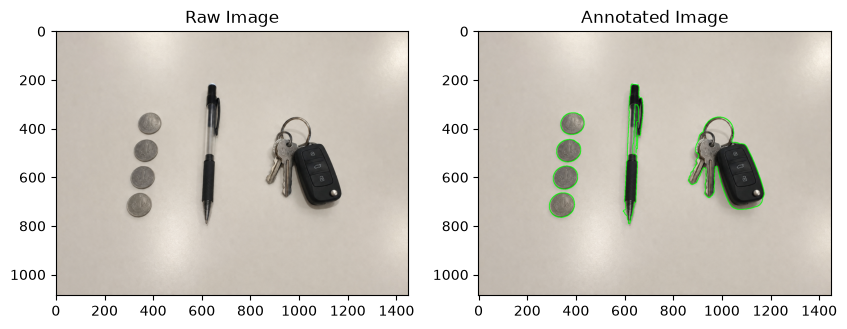

In [63]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(image_rgb)
axes[0].set_title("Raw Image")
axes[1].imshow(annotated_rgb)
axes[1].set_title("Annotated Image")

### Save the Results

In [65]:
fig.savefig("annotated.png")